# LLM 원리 + OpenAI Chat Completion API 활용

---

## 학습 목표

1. **LLM 기본 개념**: 트랜스포머 아키텍처와 토큰 예측 원리 이해
2. **OpenAI API 기초**: Chat Completion API의 기본 사용법 습득
3. **멀티모달 활용**: 텍스트, 이미지, 오디오를 처리하는 방법 학습
4. **구조화된 출력**: JSON Schema를 사용한 구조화된 응답 생성
5. **매개변수 최적화**: Temperature, Top-p 등 주요 매개변수 활용
6. **다양한 API**: Embeddings, Moderation, Function Calling, Streaming 활용

---

## 1. LLM 기본 개념

### 1.1 LLM(Large Language Model)의 생성 원리

**LLM은 어떻게 작동하나요?**
- **트랜스포머 구조**: 대화형 AI의 핵심 아키텍처
- **토큰 예측**: 다음에 올 가장 적절한 단어를 예측
- **학습 방식**: 인터넷의 방대한 텍스트 데이터로 사전 훈련

**핵심 프로세스**
1. **토큰화**: 텍스트를 작은 단위(토큰)로 분할
2. **확률 계산**: 각 토큰이 다음에 올 확률 계산
3. **토큰 생성**: 확률 분포에 따라 토큰 선택
4. **반복**: 종료 조건까지 과정 반복


**트랜스포머**:
- **인코더-디코더 구조**: 입력과 출력을 동시에 처리
- **어텐션 메커니즘**: 입력의 모든 부분을 동시에 고려하여 중요한 정보에 집중


<div style="text-align: left; font-size: 12px;">
<div style="text-align: center;">
    <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/3/34/Transformer%2C_full_architecture.png/440px-Transformer%2C_full_architecture.png"
        alt="Illustrations for the Transformer and attention mechanism showing the full Transformer architecture"
        width="600"
        style="border: 0;">
</div>

**Image Title:** Transformer Architecture Illustration  
**Source:** [GitHub - DL Visuals](https://github.com/dvgodoy/dl-visuals/?tab=readme-ov-file)  
**License:** [Creative Commons Attribution 4.0 International License](https://creativecommons.org/licenses/by/4.0/)  
**Author(s):** dvgodoy  

</div>

---

## 2. OpenAI API 핵심 개념

### 1.1 주요 구성 요소

**1. 메시지 형식**

  ```python
  messages = [
      {"role": "system", "content": "당신은 도움이 되는 AI 어시스턴트입니다."},
      {"role": "user", "content": "파이썬에서 리스트를 정렬하는 방법을 알려주세요."},
      {"role": "assistant", "content": "sort() 메서드나 sorted() 함수를 사용할 수 있습니다."}
  ]
  ```

**2. 현재 사용 가능한 주요 모델 (2025년 기준)**

  - **gpt-4.1**: 최고 성능, 복잡한 작업용
  - **gpt-4.1-mini**: 빠른 속도, 비용 효율적
  - **gpt-4.1-nano**: 초고속, 최저 비용
  - **o3, o4-mini**: 복잡한 추론 작업용
  - **gpt-4o**: 멀티모달 (텍스트, 이미지, 오디오)

  > ** 참고**: 모델 목록은 지속적으로 업데이트됩니다. 최신 모델 정보는 [OpenAI Platform - Models](https://platform.openai.com/docs/models)에서 확인하세요.

**3. API 응답 구조**

  ```json
  {
    "id": "chatcmpl-...",
    "object": "chat.completion",
    "model": "gpt-4.1-mini",
    "choices": [
      {
        "message": {
          "role": "assistant", 
          "content": "생성된 텍스트"
        }
      }
    ],
    "usage": {
      "prompt_tokens": 10,
      "completion_tokens": 50,
      "total_tokens": 60
    }
  }
  ```


---

## 3. 환경 설정


- **uv 프로젝트 설정**
    - **프로젝트 생성**: `uv init [프로젝트명]`
    - **가상환경 생성**: `uv venv --python=3.12`
    - **가상환경 활성화**: `.venv/bin/activate` (Unix) 또는 `.venv\Scripts\activate` (Windows)


- **패키지 설치**

    ```bash
    # uv 사용 (권장)
    uv add langchain langchain_openai python-dotenv ipykernel

    # pip 사용
    pip install langchain langchain_openai python-dotenv ipykernel
    ```

- **API 키 설정**

    ```python
    # .env 파일 생성
    OPENAI_API_KEY=your_api_key_here

    # Python에서 로드
    from dotenv import load_dotenv
    import os

    load_dotenv()
    OPENAI_API_KEY = os.getenv("OPENAI_API_KEY") # OPENAI_API_KEY = LangChain 문서상 정의되어있는 명칭
    ```


In [ ]:
from dotenv import load_dotenv
load_dotenv()  # .env 파일에서 환경 변수 로드

True

In [2]:
import os
# os.getenv("OPENAI_API_KEY") # API key 확인, 단 이렇게 소스코드에 key 있는 건 보안상 권장되지 않음 -> 환경변수로 관리, 환경변수는 .gitignore 대상


---

## 4. 기본 사용법

### 4.1 텍스트 답변을 생성

* OpenAI 클라이언트 설정
  - `from openai import OpenAI`로 OpenAI 패키지를 임포트합니다
  - `client = OpenAI()`로 API 클라이언트를 생성합니다
  - API 키는 환경변수나 직접 설정을 통해 제공할 수 있습니다
  - 보안을 위해 API 키는 `.env` 파일이나 환경변수를 통해 관리하는 것이 권장됩니다

* Chat Completion 요청 구조
  - `client.chat.completions.create()`를 통해 텍스트 생성을 요청합니다
  - `model`: 사용할 모델을 지정 (예: "gpt-4.1-mini")
  - `messages`: 대화 맥락을 리스트 형태로 전달
    - `role`: "system", "user" 등의 역할 지정
    - `content`: 실제 메시지 내용
  - `temperature`: 생성 텍스트의 무작위성 조절 (0~1)
  - `max_tokens`: 생성될 최대 토큰 수 제한

* 응답 처리
  - API는 JSON 형태로 응답을 반환합니다
  - `response.choices[0].message.content`: 생성된 분석 텍스트
  - `response.usage`: 토큰 사용량 정보
  - `response.id`: 응답의 고유 식별자
  - `response.model`: 사용된 모델 정보


In [3]:
# OpenAI API를 직접 사용하는 방법 (에러 처리 포함)
from openai import OpenAI
from openai import OpenAIError, APIError, RateLimitError, APIConnectionError

# 통신을 위한 클라이언트 생성 (.env 파일을 사용하지 않는 경우에는 주석을 해제하고 api_key를 직접 입력)
client = OpenAI(
    # api_key = OPENAI_API_KEY,
)

# 2026.2.4(수) 20h15 내가 발급받은 openAi api 동작 잘 되는지 확인
try:
    # Completion 요청 (prompt -> completion)
    response = client.chat.completions.create(
        model="gpt-4.1-mini-2025-04-14", # 모델마다 시간 인식 오류 있음 <- 모델은 과거에 머물러 있음 -> 프롬프트에 '오늘, 최근, 최신' 등의 단어 사용하는 거 위험, 정확한 일시를 제공해야 함
        messages=[
            # system 역할 - 전반적인 동작 방식 정의 (GPT-4 계열에서 권장)
            {"role": "system", "content": "You are a helpful programming assistant."},
            # user 역할 - 실제 요청 내용
            {"role": "user", "content": "오늘 날짜는 언제인가요?"},
        ],
        temperature=0.7, # 21h45 나의 질문 = temperature 특정 값에 대해, 또는 값 바꿔가면서, 반복 api 호출해서 답 비교/평가하는 애플리케이션/프로그램은 어떻게 생겼을까?
        max_tokens=2000, # 토큰 = 단어
    )
    
    # 결과 출력
    print(response) # 응답 객체 전체 출력
    print("="*100)
    print("id:", response.id)
    print("-"*100)
    print('model:', response.model)
    print("-"*100)
    print("text:", response.choices[0].message.content)
    print("-"*100)
    print("usage:", response.usage) # completion_tokens = 답변, prompt_tokens = 질문

except RateLimitError as e:
    print(f"⚠️ Rate Limit 오류: API 사용량 한도를 초과했습니다. 잠시 후 다시 시도해주세요.")
    print(f"상세 정보: {e}")
except APIConnectionError as e:
    print(f"⚠️ 연결 오류: OpenAI API 서버에 연결할 수 없습니다. 네트워크 연결을 확인해주세요.")
    print(f"상세 정보: {e}")
except APIError as e:
    print(f"⚠️ API 오류: OpenAI API에서 오류가 발생했습니다.")
    print(f"상세 정보: {e}")
except OpenAIError as e:
    print(f"⚠️ OpenAI 오류: {e}")
except Exception as e:
    print(f"⚠️ 예상치 못한 오류가 발생했습니다: {e}")

ChatCompletion(id='chatcmpl-DBFwqJQYwoV8r3Sti0dB3WBaEdRU2', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='오늘 날짜는 2024년 6월 13일입니다.', refusal=None, role='assistant', annotations=[], audio=None, function_call=None, tool_calls=None))], created=1771575284, model='gpt-4.1-mini-2025-04-14', object='chat.completion', service_tier='default', system_fingerprint='fp_cde3adbea5', usage=CompletionUsage(completion_tokens=15, prompt_tokens=25, total_tokens=40, completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=0, audio_tokens=0, reasoning_tokens=0, rejected_prediction_tokens=0), prompt_tokens_details=PromptTokensDetails(audio_tokens=0, cached_tokens=0)))
id: chatcmpl-DBFwqJQYwoV8r3Sti0dB3WBaEdRU2
----------------------------------------------------------------------------------------------------
model: gpt-4.1-mini-2025-04-14
------------------------------------------------------------------------------------------------

In [4]:
# 결과 출력 (Markdown)
from IPython.display import Markdown, display

display(Markdown(response.choices[0].message.content))

오늘 날짜는 2024년 6월 13일입니다.

---
여기부터는 정보 구조화하는 지능 중요, 상용 모델 vs 오픈소스 모델 성능 차이 많이 남
### 4.2 구조화된 JSON (객체) 출력

구조화된 출력은 데이터 처리와 분석에 용이하며, API 응답의 일관성을 보장합니다.

* JSON Schema 정의
  - `response_format`을 통해 응답의 형식을 JSON으로 지정합니다
  - `json_schema`에서 데이터 구조와 각 필드의 특성을 정의합니다
    - `type`: 데이터 타입 (string, number 등)
    - `description`: 각 필드에 대한 설명
    - `required`: 필수 필드 지정
    - `additionalProperties`: 추가 속성 허용 여부

* 정보 추출 과정
  - 입력된 텍스트에서 정규화된 형태로 정보를 추출
  - 지정된 스키마에 맞춰 JSON 객체 구성
  - 필수 필드가 누락되지 않도록 검증
  - 가격과 같은 숫자 정보는 적절한 형식으로 변환

In [5]:
from openai import OpenAI
client = OpenAI()

response = client.chat.completions.create(
    model="gpt-4.1-mini-2025-04-14",
    messages=[
        {
            "role": "system",
            "content": "상품 정보를 구조화된 형태로 추출하고, 각 속성에 대해 자세히 설명합니다."
        },
        {
            "role": "user",
            "content": "애플 아이폰 15 프로 256GB (블랙) - 1,500,000원"
        }
    ],
    response_format={
        "type": "json_schema",
        "json_schema": {
            "name": "product_schema",
            "description": "상품의 상세 정보를 구조화하기 위한 스키마",
            "schema": {
                "type": "object",
                "properties": {
                    "brand": {
                        "type": "string",
                        "description": "제조사 또는 브랜드 이름 (예: 애플, 삼성, LG 등)"
                    },
                    "model": {
                        "type": "string",
                        "description": "제품의 모델명 또는 시리즈명"
                    },
                    "capacity": {
                        "type": "string",
                        "description": "저장 용량 또는 규격 (예: 256GB, 512GB 등)"
                    },
                    "color": {
                        "type": "string",
                        "description": "제품의 색상"
                    },
                    "price": {
                        "type": "number",
                        "description": "제품의 가격 (단위: 원)",
                        "minimum": 0
                    },
                    "category": {
                        "type": "string",
                        "description": "제품의 카테고리 (예: 스마트폰, 노트북 등)"
                    },
                },
                "required": ["brand", "model", "price"],
                "additionalProperties": False
            }
        }
    }
)

# 결과 출력
print(response)
print("="*100)
print("id:", response.id)
print("-"*100)
print('model:', response.model)
print("-"*100)
print("text:", response.choices[0].message.content)
print("-"*100)
print("usage:", response.usage)

ChatCompletion(id='chatcmpl-DBFwswsywCe6JBEvDdxpjH8QzyLeP', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='{"brand":"애플","model":"아이폰 15 프로","capacity":"256GB","color":"블랙","price":1500000,"category":"스마트폰"}', refusal=None, role='assistant', annotations=[], audio=None, function_call=None, tool_calls=None))], created=1771575286, model='gpt-4.1-mini-2025-04-14', object='chat.completion', service_tier='default', system_fingerprint='fp_d94e893512', usage=CompletionUsage(completion_tokens=36, prompt_tokens=404, total_tokens=440, completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=0, audio_tokens=0, reasoning_tokens=0, rejected_prediction_tokens=0), prompt_tokens_details=PromptTokensDetails(audio_tokens=0, cached_tokens=0)))
id: chatcmpl-DBFwswsywCe6JBEvDdxpjH8QzyLeP
----------------------------------------------------------------------------------------------------
model: gpt-4.1-mini-2025-04-14
-----------------

In [6]:
import json

data = json.loads(response.choices[0].message.content)
data

{'brand': '애플',
 'model': '아이폰 15 프로',
 'capacity': '256GB',
 'color': '블랙',
 'price': 1500000,
 'category': '스마트폰'}

---

### 4.3 이미지 분석 (멀티모달)

OpenAI API를 사용한 이미지 분석(멀티모달 기능을 통해 이미지에 대한 상세 분석과 설명을 자연어로 얻을 수 있습니다.


* 이미지 입력 방식
  - URL 방식
    - 웹상의 이미지 URL을 직접 전달
    - `image_url` 파라미터를 통해 이미지 URL 지정
    - 인터넷 접근이 가능한 이미지에 대해 사용
  
  - Base64 인코딩 방식
    - 로컬 이미지 파일을 Base64 문자열로 변환
    - `encode_image()` 함수로 이미지 파일을 Base64로 인코딩
    - 인코딩된 문자열을 `data:image/jpeg;base64,` 형식으로 전달
    - 로컬 이미지나 비공개 이미지 처리에 적합

* API 요청 구조
  - `messages` 배열에 멀티모달 컨텐츠 포함
    - `type`: "text" 또는 "image_url"로 컨텐츠 유형 구분
    - 텍스트와 이미지를 함께 전달 가능
    - `role`을 통해 개발자/사용자 역할 지정


`(1) 이미지 URL 사용`

> **필요 파일**: Base64 예제에서 사용하는 `data/celltrion_report_chart.jpg` 파일이 필요합니다.

- uv add pillow

In [7]:
# 이미지 출력
from IPython.display import Image, display

# 예시 이미지 URL
image_url = "https://upload.wikimedia.org/wikipedia/commons/thumb/d/dd/Gfp-wisconsin-madison-the-nature-boardwalk.jpg/600px-Gfp-wisconsin-madison-the-nature-boardwalk.jpg"

# 노트북에 이미지 출력
display(Image(url=image_url))

이미지 크기: (600, 391)
이미지 모드: RGB
이미지 포맷: JPEG


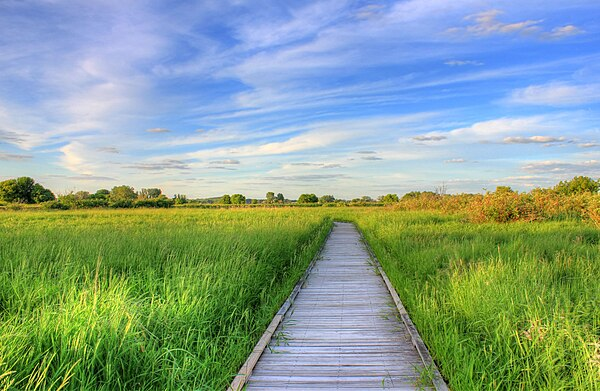

이미지 다운로드 및 표시 완료!


In [8]:
import httpx
import asyncio
from PIL import Image
from io import BytesIO

async def download_and_display_image(image_url):
    """이미지를 비동기로 다운로드하고 표시하는 함수"""
    
    async with httpx.AsyncClient(headers={'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'}) as client:
        # 비동기로 이미지 다운로드
        response = await client.get(image_url)
        
        # 응답 상태 확인
        response.raise_for_status()
        
        # 이미지 열기
        img = Image.open(BytesIO(response.content))
        
        # 이미지 정보 출력
        print(f"이미지 크기: {img.size}")
        print(f"이미지 모드: {img.mode}")
        print(f"이미지 포맷: {img.format}")
        
        # 이미지 출력
        display(img)
        
        return img


try:
    img = await download_and_display_image(image_url)
    print("이미지 다운로드 및 표시 완료!")
except httpx.HTTPError as e:
    print(f"HTTP 에러 발생: {e}")
except Exception as e:
    print(f"일반 에러 발생: {e}")

In [9]:
from openai import OpenAI

client = OpenAI()

response = client.chat.completions.create(
    model="gpt-4.1-mini",
    messages=[
        {
            "role": "user",
            "content": [
                {
                    "type": "text",
                    "text": "What's in this image? Answer in 한국어."}, # 프롬프트 일부에 한국어 명시적으로 밝히는 것도 좋음 -> 사용자가 한국어 사용한다는 힌트를 줌
                {
                    "type": "image_url",
                    "image_url": {
                        "url": image_url,
                    }
                },
            ],
        }
    ],
)

# 결과 출력
print(response)
print("="*100)
print("id:", response.id)
print("-"*100)
print('model:', response.model)
print("-"*100)
print("text:", response.choices[0].message.content)
print("-"*100)
print("usage:", response.usage)

ChatCompletion(id='chatcmpl-DBFxB8a7UL0f9YaD79fkqnl6b0p1P', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='이 이미지는 넓은 초원이나 들판 가운데 나무로 만든 보도교가 뻗어 있는 모습을 보여줍니다. 양쪽으로는 초록색 풀들이 무성하게 자라 있고, 하늘은 파란색 바탕에 흰 구름이 흩어져 있어 맑고 평화로운 자연 풍경을 나타내고 있습니다.', refusal=None, role='assistant', annotations=[], audio=None, function_call=None, tool_calls=None))], created=1771575305, model='gpt-4.1-mini-2025-04-14', object='chat.completion', service_tier='default', system_fingerprint='fp_a391f2cee0', usage=CompletionUsage(completion_tokens=81, prompt_tokens=419, total_tokens=500, completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=0, audio_tokens=0, reasoning_tokens=0, rejected_prediction_tokens=0), prompt_tokens_details=PromptTokensDetails(audio_tokens=0, cached_tokens=0)))
id: chatcmpl-DBFxB8a7UL0f9YaD79fkqnl6b0p1P
----------------------------------------------------------------------------------------------------
model: gpt-4.1-mini-2

`(2)  Base 64 encoded format 사용`

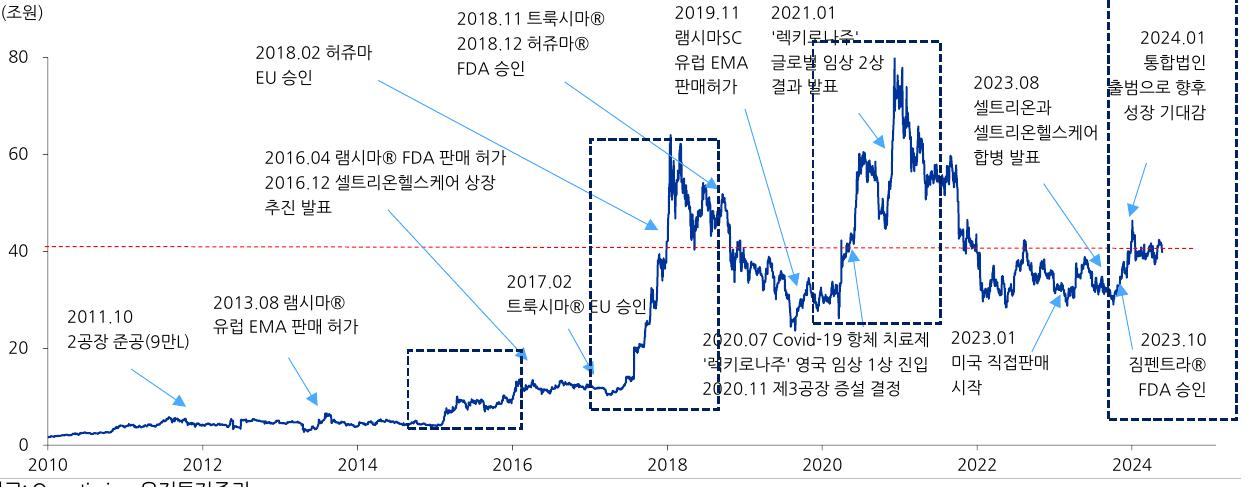

In [10]:
# 로컬 이미지 파일 경로
image_path = "data/celltrion_report_chart.jpg"

# 이미지 출력
img = Image.open(image_path)
display(img)

In [11]:
import base64

def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode("utf-8")

# 이미지를 base64 포맷 문자열로 변환
base64_image = encode_image(image_path)

base64_image

'...'

In [12]:
import base64
from openai import OpenAI

client = OpenAI()

# 이전 셀에서 정의한 encode_image 함수 재사용
# 이미지를 base64 포맷 문자열로 변환
base64_image = encode_image(image_path)

response = client.chat.completions.create(
    model="gpt-4.1-mini",
    messages=[
        {
            "role": "system",
            "content": [
                {
                    "type": "text",
                    "text": """You are a financial chart analyst. For any chart:
                            1. Identify the financial metrics being displayed
                            2. Note key price levels, support/resistance areas
                            3. Identify significant trends and pattern formations
                            4. Calculate relevant indicators (if visible)
                            5. Highlight trading volume patterns
                            6. Point out any significant market events
                            7. Provide technical analysis insights
                            Be specific with price levels and dates. Answer in 한국어."""
                }
            ]
        },
        {
            "role": "user",
            "content": [
                {
                    "type": "text",
                    "text": "What does this chart show?"
                },
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/jpeg;base64,{base64_image}"
                    }
                }
            ]
        }
    ]
)

print(response.choices[0])

Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='이 차트는 2010년부터 2024년까지 한 기업(아마도 셀트리온헬스케어 관련)의 기업가치 또는 매출액(단위: 조원) 변화를 시간 순서에 따라 보여주고 있습니다. \n\n1. 재무 지표: Y축은 조단위(조원)로 표시된 금액, 아마도 기업의 가치 또는 매출액 추이로 보입니다.\n2. 주요 가격/가치 수준: \n   - 2016년 전후 약 20조원대\n   - 2018년 최고점 약 70조원 근처 도달\n   - 이후 등락 반복, 2024년에는 약 40조원 수준에서 안정화\n3. 주요 이벤트 및 승인:\n   - 2011년 10월 2공장 준공(9만L)\n   - 2013년 8월 램시마® 유럽 EMA 판매 허가\n   - 2016년 4월 램시마® FDA 판매 허가, 12월 셀트리온헬스케어 상장 추진 발표\n   - 2017~2018년 트룩시마®, 허쥬마® EU·FDA 승인\n   - 2019년 11월 램시마SC 유럽 EMA 판매허가\n   - 2020년 7월 코로나19 항체 치료제 ‘렉키로나주’ 임상 진입 및 11월 제3공장 증설 결정\n   - 2021년 1월 렉키로나주 글로벌 임상 2상 결과 발표\n   - 2023년 1월 미국 직접판매 시작, 8월 셀트리온과 셀트리온헬스케어 합병 발표\n   - 2023년 10월 짐펜트라® FDA 승인\n   - 2024년 1월 통합법인 출범 및 성장 기대감\n4. 트렌드 분석:\n   - 2016년 이후 시작된 여러 임상 및 FDA·EMA 승인 발표로 인해 기업가치가 급증.\n   - 2018년 이후부터는 임상 결과 및 판매 허가 관련 발표에 따라 변동성 커짐.\n   - 최근에는 40조원 부근에서 비교적 안정적 움직임.\n5. 시장 이벤트에 따른 변동 큼:\n   - 승인 발표 시 급격히 주가나 가치 상승\n   - 임상 결과 발표 및 합병, 증설 결정이 변동성에 

In [13]:
print(response.choices[0].message.content)

이 차트는 2010년부터 2024년까지 한 기업(아마도 셀트리온헬스케어 관련)의 기업가치 또는 매출액(단위: 조원) 변화를 시간 순서에 따라 보여주고 있습니다. 

1. 재무 지표: Y축은 조단위(조원)로 표시된 금액, 아마도 기업의 가치 또는 매출액 추이로 보입니다.
2. 주요 가격/가치 수준: 
   - 2016년 전후 약 20조원대
   - 2018년 최고점 약 70조원 근처 도달
   - 이후 등락 반복, 2024년에는 약 40조원 수준에서 안정화
3. 주요 이벤트 및 승인:
   - 2011년 10월 2공장 준공(9만L)
   - 2013년 8월 램시마® 유럽 EMA 판매 허가
   - 2016년 4월 램시마® FDA 판매 허가, 12월 셀트리온헬스케어 상장 추진 발표
   - 2017~2018년 트룩시마®, 허쥬마® EU·FDA 승인
   - 2019년 11월 램시마SC 유럽 EMA 판매허가
   - 2020년 7월 코로나19 항체 치료제 ‘렉키로나주’ 임상 진입 및 11월 제3공장 증설 결정
   - 2021년 1월 렉키로나주 글로벌 임상 2상 결과 발표
   - 2023년 1월 미국 직접판매 시작, 8월 셀트리온과 셀트리온헬스케어 합병 발표
   - 2023년 10월 짐펜트라® FDA 승인
   - 2024년 1월 통합법인 출범 및 성장 기대감
4. 트렌드 분석:
   - 2016년 이후 시작된 여러 임상 및 FDA·EMA 승인 발표로 인해 기업가치가 급증.
   - 2018년 이후부터는 임상 결과 및 판매 허가 관련 발표에 따라 변동성 커짐.
   - 최근에는 40조원 부근에서 비교적 안정적 움직임.
5. 시장 이벤트에 따른 변동 큼:
   - 승인 발표 시 급격히 주가나 가치 상승
   - 임상 결과 발표 및 합병, 증설 결정이 변동성에 큰 영향 주는 모습
6. 종합적 시사점:
   - 바이오 의약품 개발 및 승인과 직접적인 연동되는 기업 가치 추이
   - FDA, EMA 승인과 주요 임상시험 결과가 기업가치 급등락의 주요 변수
   - 2

---

### 4.4 오디오 출력


OpenAI API의 음성 생성(Text-to-Speech) 기능을 통해 텍스트 응답을 자연스러운 음성으로 변환하여 활용할 수 있습니다.

* API 요청 설정
  - `model`: "gpt-4o-mini-audio-preview"와 같은 오디오 지원 모델 사용
  - `modalities`: ["text", "audio"]로 텍스트와 오디오 모두 출력
  - `audio` 파라미터 설정
    - `voice`: 음성 종류 선택 (예: "alloy")
    - `format`: 출력 포맷 지정 (예: "wav")

* 음성 생성 과정
  - API는 텍스트 응답과 함께 Base64로 인코딩된 오디오 데이터 반환
  - 응답 구조:
    - `completion.choices[0].message.content`: 텍스트 응답
    - `completion.choices[0].message.audio.data`: Base64 인코딩된 오디오 데이터

* 오디오 파일 저장
  - Base64 디코딩
    ```python
        wav_bytes = base64.b64decode(completion.choices[0].message.audio.data)
    ```
  - 파일로 저장
    ```python
        with open("sample.wav", "wb") as f:
            f.write(wav_bytes)
    ```

In [14]:
from openai import OpenAI

client = OpenAI()

completion = client.chat.completions.create(
    model="gpt-4o-mini-audio-preview",
    modalities=["text", "audio"], # 멀티모달
    audio={"voice": "alloy", "format": "wav"}, # 답변을 음성으로 하도록 함
    messages=[
        {
            "role": "user",
            "content": "안녕하세요. 대한민국의 수도는 어디인가요?"
        }
    ]
)

print(completion.choices[0])

Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content=None, refusal=None, role='assistant', annotations=[], audio=ChatCompletionAudio(id='audio_69981820dd548191b88a31ee289bfd3b', data='...', expires_at=1771578928, transcript='안녕하세요! 대한민국의 수도는 서울입니다.'), function_call=None, tool_calls=None))


In [15]:
# 음성 파일 저장
import base64

wav_bytes = base64.b64decode(completion.choices[0].message.audio.data)
with open("sample.wav", "wb") as f:
    f.write(wav_bytes)

In [16]:
# 토큰 사용량
print(completion.usage)

CompletionUsage(completion_tokens=89, prompt_tokens=18, total_tokens=107, completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=0, audio_tokens=69, reasoning_tokens=0, rejected_prediction_tokens=0, text_tokens=20), prompt_tokens_details=PromptTokensDetails(audio_tokens=0, cached_tokens=0, text_tokens=18, image_tokens=0))


---


**[실습 1]**: OpenAI 클라이언트를 초기화하고 환경변수에서 API 키를 가져오도록 코드를 작성하세요.
- `힌트: python-dotenv 패키지를 사용하세요.`


In [17]:
# 여기에 코드를 작성하세요
# 힌트:
# 1. from dotenv import load_dotenv 임포트
from dotenv import load_dotenv

# 2. load_dotenv()로 .env 파일 로드
load_dotenv()

# 3. from openai import OpenAI 임포트
from openai import OpenAI

# 4. client = OpenAI()로 클라이언트 초기화
client = OpenAI()


**[실습 2]**: 주어진 프롬프트에 대해 OpenAI API(gpt-4.1-mini)로 응답을 생성하는 함수를 작성하세요.

In [18]:
from openai import OpenAI

def get_simple_completion(prompt: str) -> str:
    client = OpenAI() # 환경 변수에 OPENAI_API_KEY가 설정되어 있다고 가정

    # 힌트:
    # 1. client.chat.completions.create() 호출
    response = client.chat.completions.create(
        # 2. model="gpt-4.1-mini" 지정
        model = "gpt-4.1-mini",
        
        # 3. messages에 user role로 prompt 전달
        messages = [
            {
                "role": "user",
                "content": [
                    {
                        "type": "text",
                        "text": prompt
                    }
                ]
            }
        ]        
    )
    
    # 4. response.choices[0].message.content 반환
    return response.choices[0].message.content

# 함수 테스트 예시
result = get_simple_completion("what is LOVE?")
print(result)

    

Love is a complex and multifaceted emotion that encompasses a range of feelings, behaviors, and beliefs associated with strong affection, warmth, and attachment toward someone or something. It can manifest in different forms, such as romantic love, familial love, platonic love, and self-love. At its core, love often involves care, compassion, trust, respect, and a desire for the well-being of the loved one. It can inspire deep connection and fulfillment, but can also involve vulnerability and sacrifice. Philosophers, poets, scientists, and artists have all explored love, highlighting its profound significance in human experience.


---

## 5. 매개변수 최적화

### 5.1 주요 매개변수 

| 매개변수 | 범위 | 용도 | 추천값 |
|---------|------|------|--------|
| `temperature` | 0~2 | 창의성 조절 | 0.3 (정확성), 0.7 (균형), 1.2 (창의성) |
| `top_p` | 0~1 | 응답 다양성 | 0.9 (기본), 0.3 (집중적) |
| `max_tokens` | 1~8192+ | 최대 길이 | 작업에 따라 조절 |
| `frequency_penalty` | -2~2 | 반복 억제 | 0.3~0.6 |
| `presence_penalty` | -2~2 | 새 주제 도입 | 0.3~0.6 |

### 5.2 시나리오별 설정


**1. 정확한 정보 제공**

In [19]:
response = client.chat.completions.create(
    model="gpt-4.1-mini",
    messages=[{"role": "user", "content": "파이썬 딕셔너리 메서드들을 설명해주세요."}],
    temperature=0.2,  # 낮은 창의성
    top_p=0.3,        # 집중적 응답
    max_tokens=500
)

print(response.choices[0].message.content)

파이썬 딕셔너리(dictionary)는 키(key)와 값(value)의 쌍으로 데이터를 저장하는 자료구조입니다. 딕셔너리에서 자주 사용하는 메서드들을 설명드리겠습니다.

---

### 1. `dict.get(key, default=None)`
- **설명**: 딕셔너리에서 `key`에 해당하는 값을 반환합니다. 만약 키가 없으면 `default` 값을 반환합니다. `default`를 지정하지 않으면 `None`을 반환합니다.
- **예시**:
  ```python
  d = {'a': 1, 'b': 2}
  print(d.get('a'))       # 출력: 1
  print(d.get('c'))       # 출력: None
  print(d.get('c', 0))    # 출력: 0
  ```

---

### 2. `dict.keys()`
- **설명**: 딕셔너리의 모든 키를 반환합니다. 반환값은 `dict_keys` 객체로, 리스트처럼 반복(iterate)할 수 있습니다.
- **예시**:
  ```python
  d = {'a': 1, 'b': 2}
  print(d.keys())         # 출력: dict_keys(['a', 'b'])
  ```

---

### 3. `dict.values()`
- **설명**: 딕셔너리의 모든 값을 반환합니다. 반환값은 `dict_values` 객체입니다.
- **예시**:
  ```python
  d = {'a': 1, 'b': 2}
  print(d.values())       # 출력: dict_values([1, 2])
  ```

---

### 4. `dict.items()`
- **설명**: 딕셔너리의 모든 (키, 값) 쌍을 튜플 형태로 반환합니다. 반환값은 `dict_items` 객체입니다.
- **예시**:
  ```python
  d = {'a': 1, 'b': 2}
  print(d.items())        # 출력: dict_items([('a', 1), ('b', 2)])


**2. 창의적 글쓰기**

In [20]:
response = client.chat.completions.create(
    model="gpt-4.1-mini",
    messages=[{"role": "user", "content": "우주 정거장에서의 하루를 소설로 써주세요."}],
    temperature=1.1,  # 높은 창의성
    top_p=0.9,        # 다양한 표현
    max_tokens=1000,
    frequency_penalty=0.5  # 반복 방지
)

print(response.choices[0].message.content)

물론입니다. 우주 정거장에서의 하루를 배경으로 한 짧은 소설을 작성해드리겠습니다.

---

### 우주 정거장에서의 하루

새벽은 없었다. 지구에서와 달리, 우주 정거장에서는 시간의 흐름이 오롯이 장치들의 윙윙거리는 소리와 전자음으로만 구분되었다. 하지만 아린은 여전히 매일 아침 7시가 되면 알람에 맞춰 눈을 떴다. 오늘도 그녀의 하루가 시작되었다.

“굿모닝, 아린.” 인공지능 비서 ‘오리온’이 부드럽게 말했다.

“굿모닝, 오리온. 오늘 일정 알려줘.” 그녀는 유연하게 몸을 돌려 벽에 붙어 있는 스크린을 띄웠다.

“오전에는 식물 생장 실험 점검, 오후에는 지구와 영상 통화 예정입니다. 그리고 저녁엔 운동 2시간이 예약되어 있습니다.”

아린은 고개를 끄덕이고 천천히 공간을 떠다니며 준비를 시작했다. 중력이 거의 없는 이곳에서 움직임 하나하나가 조심스러웠다. 작은 실험실 모듈로 이동해 식물들이 자라고 있는 투명한 캡슐들을 살폈다. 그 안에서는 초록빛 잎사귀들이 마치 지구의 푸른 숲처럼 싱그럽게 펼쳐져 있었다.

“성장 속도가 예상보다 빨라요.” 그녀가 노트패드에 적으며 중얼거렸다.

오후가 되자 화면 속 지구는 언제나처럼 푸르고 반짝였다. 가족과 동료 우주인들의 얼굴이 반갑게 비쳤고, 잠시지만 고향의 냄새를 떠올리게 하는 대화들이 이어졌다.

시간은 무심히 흘렀고, 해가 없는 공간에서도 아린은 정해진 루틴대로 운동복으로 갈아입었다. 중력 부재 상태에서도 근육량 유지를 위해 강도 높은 트레이닝 기구에 몸을 맡겼다. 땀방울 대신 뭉클한 감정만이 그녀의 마음속에서 흘러내렸다.

“지금 이 순간에도 우리가 걸어온 길과 꿈꿀 미래가 연결되고 있어.” 아린은 숨을 고르며 조용히 다짐했다.

밤이 되자 우주선 밖으로 펼쳐진 끝없는 별들이 창문 가득히 빛났다. 그 빛들 사이에서 그녀는 오늘 하루를 되돌아보고 내일을 준비했다.

지구와 떨어진 이 먼 곳에서도, 아린의 마음은 언제나 지구와 연결되어 있었다.

---

필요하시면 더 길거나 다른 스타일로도 작성해드릴 수 있

**3. 코드 생성**

In [21]:
response = client.chat.completions.create(
    model="gpt-4.1-mini",
    messages=[{"role": "user", "content": "웹 스크래핑을 위한 Python 함수를 만들어주세요."}],
    temperature=0.4,  # 약간의 창의성
    max_tokens=800
)

print(response.choices[0].message.content)

웹 스크래핑을 위한 기본적인 Python 함수를 만들어 드리겠습니다. 보통 웹 스크래핑에는 `requests` 라이브러리로 웹페이지의 HTML을 가져오고, `BeautifulSoup`으로 HTML을 파싱하는 방식을 많이 사용합니다.

아래 예시는 특정 URL의 HTML을 가져와서, 예를 들어 모든 `<a>` 태그의 링크와 텍스트를 추출하는 함수입니다.

```python
import requests
from bs4 import BeautifulSoup

def scrape_links(url):
    """
    주어진 URL에서 모든 <a> 태그의 href와 텍스트를 추출하는 함수입니다.

    Args:
        url (str): 스크래핑할 웹페이지 URL

    Returns:
        list of dict: [{'text': 링크 텍스트, 'href': 링크 주소}, ...]
    """
    try:
        response = requests.get(url)
        response.raise_for_status()  # HTTP 에러가 있으면 예외 발생

        soup = BeautifulSoup(response.text, 'html.parser')
        links = []

        for a_tag in soup.find_all('a', href=True):
            text = a_tag.get_text(strip=True)
            href = a_tag['href']
            links.append({'text': text, 'href': href})

        return links

    except requests.RequestException as e:
        print(f"웹페이지 요청 중 오류 발생: {e}")
        return []

# 사용 예시
if __name__ == "__main__":
    url 

---

## 6. 토큰 사용량 및 비용 계산

### 6.1 토큰 사용량 이해하기

OpenAI API는 토큰 단위로 과금됩니다. 토큰은 텍스트의 작은 단위로, 영어는 약 4자당 1토큰, 한글은 약 1-2자당 1토큰입니다.

**토큰 구성**
- **prompt_tokens**: 입력 토큰 (system + user 메시지)
- **completion_tokens**: 출력 토큰 (assistant 응답)
- **total_tokens**: 전체 토큰 (입력 + 출력)

In [22]:
from openai import OpenAI

client = OpenAI()

# 예제: 토큰 사용량 확인
response = client.chat.completions.create(
    model="gpt-4.1-mini",
    messages=[
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user", "content": "파이썬에서 리스트와 튜플의 차이점을 설명해주세요."}
    ]
)

# 토큰 사용량 확인
usage = response.usage
print(f"입력 토큰: {usage.prompt_tokens}")
print(f"출력 토큰: {usage.completion_tokens}")
print(f"총 토큰: {usage.total_tokens}")
print("-" * 50)

# 비용 계산 (2025년 1월 기준 예시 가격)
# gpt-4.1-mini: 입력 $0.075 / 1M tokens, 출력 $0.300 / 1M tokens
input_cost = (usage.prompt_tokens / 1_000_000) * 0.075
output_cost = (usage.completion_tokens / 1_000_000) * 0.300
total_cost = input_cost + output_cost

print(f"입력 비용: ${input_cost:.6f}")
print(f"출력 비용: ${output_cost:.6f}")
print(f"총 비용: ${total_cost:.6f}")
print(f"총 비용 (원화): 약 {total_cost * 1500:.4f}원")
print("-" * 50)
print("\n최신 가격 정보는 https://openai.com/api/pricing 에서 확인하세요.")

입력 토큰: 34
출력 토큰: 522
총 토큰: 556
--------------------------------------------------
입력 비용: $0.000003
출력 비용: $0.000157
총 비용: $0.000159
총 비용 (원화): 약 0.2387원
--------------------------------------------------

최신 가격 정보는 https://openai.com/api/pricing 에서 확인하세요.


---

## 7. 실습 문제

**문제 1: 언어 번역기 만들기**

In [23]:
# 1. from dotenv import load_dotenv 임포트
from dotenv import load_dotenv

# 2. load_dotenv()로 .env 파일 로드
load_dotenv()

# 3. from openai import OpenAI 임포트
from openai import OpenAI

def translator(text, target_language):
    # 힌트:
    # 1. OpenAI 클라이언트 생성
    client = OpenAI()
    
    response = client.chat.completions.create(
        model="gpt-4.1-mini",
        messages=[
            # 2. system 메시지로 번역기 역할 정의
            {
                "role": "system",
                "content": [
                    {
                        "type": "text",
                        "text": "You are a professional translator of text into the target language."
                    }
                ]
            },
            # 3. user 메시지로 번역할 텍스트와 목표 언어 전달
            {
                "role": "user",
                "content": [
                    {
                        "type": "text",
                        "text": text
                    },
                    {
                        "type": "text",
                        "text": target_language
                    }
                ]
            }
        ]
    )    
    
    # 4. 응답 반환
    return response

# 테스트
result = translator("안녕하세요, 오늘 날씨가 좋네요!", "영어")
# print(result)  # 예상 출력: Hello, the weather is nice today!
print(result.choices[0].message.content)

Hello, the weather is nice today!


**문제 2: 감정 분석기**

In [24]:
import json

In [31]:
def analyze_sentiment(text):
    # 힌트:
    # 1. OpenAI 클라이언트 생성
    client = OpenAI()
    
    response = client.chat.completions.create(
         model="gpt-4.1-mini",
         messages=[
            {
                "role": "system",
                "content": "You analyze sentiment in the user input. Output only JSON that matches the given schema."
            },
            {
                "role": "user",
                "content": text
            }
         ],

         # 2. response_format에 json_schema 정의
         response_format={
            "type": "json_schema",
            # 3. sentiment와 confidence 필드를 포함하는 스키마 작성
            "json_schema": {
                "name": "sentiment_and_confidence_schema",
                "description": "sentiment와 confidence 필드를 포함하는 스키마",
                "schema": {
                    "type": "object",
                    "properties": {
                        "sentiment": {
                            "type": "string",
                            "description": "감정 분석 결과 (예: positive, negative, neutral 등)"
                        },
                        "confidence": {
                            "type": "number",
                            "description": "감정 분석 결과에 대한 신뢰도",
                            "minimum": 0
                        },
                    },
                    "required": ["sentiment", "confidence"],
                    "additionalProperties": False
                }
            }
        }
    )

    content = response.choices[0].message.content.strip()
    # 4. JSON 응답 파싱하여 반환
    return json.loads(content)

# 테스트
result = analyze_sentiment("오늘 시험을 잘 봤어요! 정말 기쁩니다.") # 오늘 시험을 잘 봤어요! 정말 기쁩니다. / 혼자 여행 중인데, 이 멋진 바다를 혼자 보니까 외롭네요 ㅠㅠ
print(result)
# 예상 출력: {'sentiment': 'positive', 'confidence': 0.95} / {'sentiment': 'negative', 'confidence': 0.85}


{'sentiment': 'positive', 'confidence': 0.98}


---

## 8. OpenAI 다양한 API 활용

### 8.1 Embeddings API - 텍스트 임베딩

텍스트를 벡터로 변환하여 유사도 검색, 클러스터링, 분류 등에 활용할 수 있습니다.

**주요 용도**
- 문서 유사도 검색
- 시맨틱 검색 (의미 기반 검색)
- 추천 시스템
- 텍스트 분류 및 클러스터링

In [26]:
from openai import OpenAI
import numpy as np

client = OpenAI()

# 텍스트를 벡터로 변환
texts = [
    "파이썬은 프로그래밍 언어입니다.",
    "Python is a programming language.",
    "사과는 과일입니다.",
    "Apple is a fruit."
]

# 임베딩 생성
embeddings = []
for text in texts:
    response = client.embeddings.create(
        model="text-embedding-3-small",  # 또는 "text-embedding-3-large"
        input=text
    )
    embeddings.append(response.data[0].embedding)

# 벡터 차원 확인
print(f"임베딩 벡터 차원: {len(embeddings[0])}")
print(f"첫 10개 값: {embeddings[0][:10]}")
print("-" * 50)

# 코사인 유사도 계산
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

# 유사도 비교
print("\n📊 유사도 분석:")
print(f"'{texts[0]}' vs '{texts[1]}': {cosine_similarity(embeddings[0], embeddings[1]):.4f}")
print(f"'{texts[0]}' vs '{texts[2]}': {cosine_similarity(embeddings[0], embeddings[2]):.4f}")
print(f"'{texts[2]}' vs '{texts[3]}': {cosine_similarity(embeddings[2], embeddings[3]):.4f}")

임베딩 벡터 차원: 1536
첫 10개 값: [-0.007588762789964676, 0.06303752213716507, -0.0014275157591328025, -0.014733738265931606, 0.040177542716264725, -0.011400402523577213, -0.027514811605215073, -0.0022559186909347773, -0.034319549798965454, -0.00017181348812300712]
--------------------------------------------------

📊 유사도 분석:
'파이썬은 프로그래밍 언어입니다.' vs 'Python is a programming language.': 0.4490
'파이썬은 프로그래밍 언어입니다.' vs '사과는 과일입니다.': 0.1717
'사과는 과일입니다.' vs 'Apple is a fruit.': 0.2460


### 8.2 Moderation API - 콘텐츠 검열

부적절한 콘텐츠를 자동으로 감지하여 필터링할 수 있습니다.

**감지 카테고리**
- 폭력적인 콘텐츠
- 혐오 발언
- 성적인 콘텐츠
- 자해 관련 내용

In [27]:
from openai import OpenAI

client = OpenAI()

# 콘텐츠 검열 예제
texts_to_check = [
    "오늘 날씨가 정말 좋네요!",
    "I want to hurt someone",  # 부적절한 예시
]

for text in texts_to_check:
    response = client.moderations.create(
        model="omni-moderation-latest",  # 또는 "text-moderation-latest"
        input=text
    )
    
    result = response.results[0]
    print(f"\n텍스트: {text}")
    print(f"위반 여부: {result.flagged}")
    
    if result.flagged:
        print("감지된 카테고리:")
        categories = result.categories
        for category, flagged in vars(categories).items():
            if flagged:
                print(f"  - {category}")
    print("-" * 50)


텍스트: 오늘 날씨가 정말 좋네요!
위반 여부: False
--------------------------------------------------

텍스트: I want to hurt someone
위반 여부: True
감지된 카테고리:
  - violence
--------------------------------------------------


### 8.3 Function Calling - 함수 호출

LLM이 외부 함수를 호출하여 동적인 작업을 수행할 수 있습니다.

**주요 사용 사례**
- API 호출 (날씨, 주식 정보 등)
- 데이터베이스 쿼리
- 계산 수행
- 외부 도구 연동

In [28]:
import json
from openai import OpenAI

client = OpenAI()

# 1. 함수 정의 (실제 실행될 함수)
def get_current_weather(location, unit="celsius"):
    """날씨 정보를 가져오는 함수 (예시)"""
    # 실제로는 날씨 API를 호출하지만, 여기서는 더미 데이터 반환
    weather_data = {
        "location": location,
        "temperature": "22",
        "unit": unit,
        "forecast": "맑음"
    }
    return json.dumps(weather_data, ensure_ascii=False)

# 2. 함수 스키마 정의 (LLM에게 알려줄 함수 정보)
tools = [
    {
        "type": "function",
        "function": {
            "name": "get_current_weather",
            "description": "특정 위치의 현재 날씨를 가져옵니다",
            "parameters": {
                "type": "object",
                "properties": {
                    "location": {
                        "type": "string",
                        "description": "도시명 (예: 서울, 부산)"
                    },
                    "unit": {
                        "type": "string",
                        "enum": ["celsius", "fahrenheit"],
                        "description": "온도 단위"
                    }
                },
                "required": ["location"]
            }
        }
    }
]

# 3. LLM에게 질문
messages = [{"role": "user", "content": "서울의 날씨가 어때?"}]

response = client.chat.completions.create(
    model="gpt-4.1-mini",
    messages=messages,
    tools=tools,
    tool_choice="auto"  # LLM이 자동으로 함수 호출 여부 결정
)

# 4. LLM이 함수를 호출하려고 하는지 확인
response_message = response.choices[0].message
tool_calls = response_message.tool_calls

if tool_calls:
    # 5. 함수 실행
    available_functions = {
        "get_current_weather": get_current_weather,
    }
    
    messages.append(response_message)
    
    for tool_call in tool_calls:
        function_name = tool_call.function.name
        function_to_call = available_functions[function_name]
        function_args = json.loads(tool_call.function.arguments)
        
        print(f"🔧 함수 호출: {function_name}")
        print(f"   인자: {function_args}")
        
        # 실제 함수 실행
        function_response = function_to_call(**function_args)
        print(f"   결과: {function_response}")
        
        # 6. 함수 실행 결과를 LLM에게 전달
        messages.append({
            "tool_call_id": tool_call.id,
            "role": "tool",
            "name": function_name,
            "content": function_response,
        })
    
    # 7. 최종 응답 생성
    final_response = client.chat.completions.create(
        model="gpt-4.1-mini",
        messages=messages,
    )
    
    print("\n💬 최종 응답:")
    print(final_response.choices[0].message.content)

🔧 함수 호출: get_current_weather
   인자: {'location': '서울', 'unit': 'celsius'}
   결과: {"location": "서울", "temperature": "22", "unit": "celsius", "forecast": "맑음"}

💬 최종 응답:
현재 서울의 날씨는 맑고, 기온은 22도입니다. 도움이 필요하시면 언제든 말씀해 주세요!


### 8.4 Streaming - 실시간 응답

응답을 실시간으로 스트리밍하여 사용자 경험을 개선할 수 있습니다.

**장점**
- 빠른 초기 응답 (First Token Time 단축)
- ChatGPT처럼 점진적으로 텍스트 생성
- 사용자에게 즉각적인 피드백 제공

In [29]:
from openai import OpenAI

client = OpenAI()

print("💬 스트리밍 응답:\n")

# stream=True로 설정하여 스트리밍 활성화
stream = client.chat.completions.create(
    model="gpt-4.1-mini",
    messages=[{"role": "user", "content": "인공지능의 역사를 간단히 설명해주세요."}],
    stream=True  # 스트리밍 활성화
)

# 실시간으로 토큰을 받아서 출력
for chunk in stream:
    # delta에 content가 있으면 출력
    if chunk.choices[0].delta.content is not None:
        print(chunk.choices[0].delta.content, end="", flush=True)

print("\n\n✅ 스트리밍 완료!")

💬 스트리밍 응답:

인공지능(AI)의 역사는 대략 다음과 같이 요약할 수 있습니다.

1. **초기 개념과 탄생 (1940~1950년대)**  
   - 앨런 튜링이 '튜링 테스트'를 제안하며 기계가 인간처럼 사고할 수 있는지에 대한 논의를 시작했습니다.  
   - 1956년 다트머스 회의에서 '인공지능'이라는 용어가 처음 사용되며 AI 연구가 본격적으로 시작되었습니다.

2. **초기 연구와 낙관론 (1950~1970년대)**  
   - 초기 AI 연구자들은 논리, 추론, 문제 해결 등을 컴퓨터로 구현하려 노력했습니다.  
   - 전문가 시스템과 같은 규칙 기반 접근법이 발전했지만, 컴퓨팅 파워의 한계와 복잡한 문제 해결의 어려움으로 제한이 있었습니다.

3. **AI 겨울 (1970~1990년대)**  
   - 기대에 미치지 못하는 성과와 자금 지원의 감소로 기업과 정부의 관심이 줄어들면서 AI 연구가 침체기를 맞았습니다.

4. **기계 학습과 데이터 혁명 (1990년대~2000년대)**  
   - 통계적 기법과 머신러닝 알고리즘이 발전하며 AI가 다시 주목받기 시작했습니다.  
   - 인터넷과 디지털 데이터의 확산으로 대량의 데이터 활용이 가능해졌습니다.

5. **딥러닝과 현대 AI (2010년대 이후)**  
   - 인공신경망을 기반으로 한 딥러닝 기술이 혁신을 일으키며 이미지 인식, 자연어 처리 등 다양한 분야에서 뛰어난 성과를 냈습니다.  
   - 구글의 알파고, 챗봇, 자율주행차 등 실생활에 적용되는 AI 기술이 급속히 발전했습니다.

이처럼 인공지능은 초기의 이론적 탐구에서 출발해, 여러 도전과 발전을 거쳐 오늘날 우리 생활 곳곳에 적용되는 핵심 기술로 자리잡았습니다.

✅ 스트리밍 완료!
